In [2]:
# Section 1 — Setup and Imports
from dotenv import load_dotenv
load_dotenv()

from typing import Literal
from pydantic import BaseModel
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langgraph.graph import StateGraph, START, END, MessagesState

In [3]:
# Section 2 — Document Loading
loader = PyPDFLoader("../documents/evs_oil_price_shock.pdf")
raw_docs = loader.load()

print(f"Loaded {len(raw_docs)} pages")

Loaded 15 pages


In [4]:
# Section 3 — Text Chunking
splitter = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150)
chunks = splitter.split_documents(raw_docs)

print(f"Split into {len(chunks)} chunks")

Split into 51 chunks


In [5]:
# Section 4 — Embedding Model
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

In [6]:
# in-memory only; re-running this cell re-embeds from scratch
vectorstore = Chroma(
    collection_name="rag_conditional",
    embedding_function=embeddings,
)

vectorstore.add_documents(documents=chunks)

retriever = vectorstore.as_retriever(search_kwargs={"k": 4})
print("Vector store ready")

Vector store ready


In [7]:
# Section 6 — LLM
llm = ChatOpenAI(model="gpt-5-mini")

In [8]:
# Section 7 — State Definition
class AgenticRAGState(MessagesState):
    
    query: str
    retrieved_docs: list[Document] | None
    context: str
    generation: str
    needs_retrieval: bool

In [9]:
# structured output schema for the routing decision
class RouteDecision(BaseModel):
    
    needs_retrieval: bool

In [10]:
# route_question node — classifies whether the query needs document retrieval
def route_question(state: AgenticRAGState) -> dict:
    
    prompt_template = ChatPromptTemplate.from_messages([
        ("system", "Classify whether the following question requires retrieving information from a specialized document, or can be answered from your own general knowledge."),
        ("human", "{query}"),
    ])
    
    chain = prompt_template | llm.with_structured_output(RouteDecision)
    decision = chain.invoke({"query": state["query"]})
    
    return {"needs_retrieval": decision.needs_retrieval}

In [11]:
# retrieve node — fetches relevant documents from the vector store
def retrieve(state: AgenticRAGState) -> dict:
    
    docs = retriever.invoke(state["query"])
    
    if docs:
        context = "\n\n".join(doc.page_content for doc in docs)

    return {"retrieved_docs": docs, "context": context}

In [12]:
# generate node — produces the final answer, with or without retrieved context
def generate(state: AgenticRAGState) -> dict:
    
    query = state["query"]
    context = state.get("context") or ""


    if context:    
        prompt_template = ChatPromptTemplate.from_messages([
            ("system", "Answer the question using only the context below.\n\nContext:\n{context}"),
            ("human", "{query}"),
        ])
        
        response = (prompt_template | llm).invoke({"context": context, "query": query})
    
    else:
        prompt_template = ChatPromptTemplate.from_messages([
            ("system", "Answer the following question from your general knowledge."),
            ("human", "{query}"),
        ])
        
        response = (prompt_template | llm).invoke({"query": query})

    return {"generation": response.content}

In [19]:
# routing function: maps needs_retrieval bool to the next node name
def route_after_classification(state: AgenticRAGState) -> Literal["retrieve", "generate"]:
    return "retrieve" if state["needs_retrieval"] else "generate"

In [20]:
# Graph Definition
graph_builder = StateGraph(AgenticRAGState)

graph_builder.add_node("needs_retrieval", route_question)
graph_builder.add_node("retrieve", retrieve)
graph_builder.add_node("generate", generate)

graph_builder.add_edge(START, "needs_retrieval")
graph_builder.add_conditional_edges("needs_retrieval", route_after_classification)
graph_builder.add_edge("retrieve", "generate")
graph_builder.add_edge("generate", END)

In [21]:
graph = graph_builder.compile()

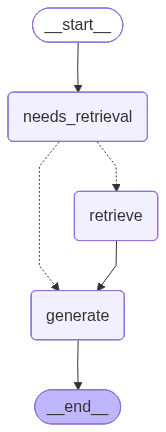

In [22]:
graph

In [23]:
# Query 1: domain-specific (should trigger retrieval)
domain_query = "What does the report say about EV adoption trajectories and oil demand displacement?"

result_domain = graph.invoke({"query": domain_query, "messages": []})

In [24]:
# Output: Query 1 (domain-specific)
print("=== QUERY 1 (domain-specific) ===")
print(f"Query          : {domain_query}")
print(f"needs_retrieval: {result_domain['needs_retrieval']}")
retrieved = result_domain.get("retrieved_docs") or []
print(f"Retrieved docs : {len(retrieved)} docs")
print(f"\nGeneration:\n{result_domain['generation']}")

=== QUERY 1 (domain-specific) ===
Query          : What does the report say about EV adoption trajectories and oil demand displacement?
needs_retrieval: True
Retrieved docs : 4 docs

Generation:
- The report says projecting oil demand displacement from EVs requires integrating three layers: annual new‑EV sales trajectories, retirement rates of the existing ICE fleet, and the mileage/fuel‑economy of the vehicles being displaced.

- The global passenger vehicle stock is about 1.4 billion (mostly ICE). With ~90 million new vehicle sales per year and 15–20 year vehicle lifetimes in developed markets (often longer in developing markets), full fleet electrification cannot happen quickly — it is constrained by turnover.

- Major forecasters (IEA, BloombergNEF, McKinsey) project EVs will make up roughly 40–60% of new vehicle sales by 2030. The EV stock is expected to grow from ~40 million today to about 300–500 million by the early 2030s.

- The report’s scope is passenger and light commercial

In [25]:
# Section 9 — Query 2: general knowledge (should skip retrieval)
general_query = "What is the capital of India?"

result_general = graph.invoke({"query": general_query, "messages": []})

In [26]:
# Output: Query 2 (general knowledge)
print("=== QUERY 2 (general knowledge) ===")
print(f"Query          : {general_query}")
print(f"needs_retrieval: {result_general['needs_retrieval']}")
print(f"Retrieved docs : {result_general.get('retrieved_docs')}")
print(f"\nGeneration:\n{result_general['generation']}")

=== QUERY 2 (general knowledge) ===
Query          : What is the capital of India?
needs_retrieval: False
Retrieved docs : None

Generation:
The capital of India is New Delhi.
